# Perception Stack - Notebook 04: Analysis and Figures

This notebook loads all inference results from Notebooks 01 and 03 and produces
the complete quantitative analysis for the Perception Stack evaluation.
All figures and tables used in the final report are generated and saved here.

## Steps
- Mount Google Drive and define all constants, condition directories, and paths
- Load inference results for all five conditions (baseline, full, no\_sam2,
  no\_depth, no\_raft) from Drive
- Aggregate per-question metrics: per-question accuracy, per-option accuracy,
  and F1 across all clips and question types
- Print the full results summary table (all conditions, all question types)
- Generate and save baseline versus full pipeline comparison figures:
  per-question accuracy bar chart, per-option accuracy bar chart, F1 bar chart
- Generate and save ablation study figures: per-question, per-option, and F1
  across all five conditions
- Generate and save delta accuracy charts: full minus baseline per question type
- Compute and save the question outcome breakdown (pipeline fixed, both correct,
  both wrong, pipeline broke it) and generate the stacked confusion bar chart
- Extract and print qualitative examples: questions fixed and broken by the pipeline
- Generate parse tier distribution and reasoning coverage figures
- Load runtime data from all condition JSONs and produce the runtime summary table;
  save as CSV

---
> **Note:** This notebook is natively developed and run on Google Colab (T4 or CPU sufficient).
> If it does not render correctly in your viewer, please open it directly on Colab:
> [Open in Google Colab](<https://colab.research.google.com/drive/1L_tZyjY2t-ePmPPebIX-wPLcGBMMK7jn?usp=sharing>)

---
# Cell 1 — Mount Drive + Constants + Paths

In [1]:
# ── Cell 1 — Mount Drive + Constants + Paths ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── CLEAR: Delete all NB04 outputs ─────────────────────────────────────────
import os

BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

# Clear NB04 figures
fig_dir = os.path.join(BASE, "figures")
deleted_figs = 0
for f in os.listdir(fig_dir):
    if f.startswith("04_"):
        os.remove(os.path.join(fig_dir, f))
        deleted_figs += 1
print(f"Deleted {deleted_figs} NB04 figures")

# Clear analysis CSVs from NB04
analysis_dir = os.path.join(BASE, "analysis")
deleted_csvs = 0
for f in os.listdir(analysis_dir):
    if f.endswith(".csv") and f not in ["baseline_summary.csv"]:
        os.remove(os.path.join(analysis_dir, f))
        deleted_csvs += 1
print(f"Deleted {deleted_csvs} analysis CSVs")

print("NB04 slate cleared.")

Deleted 0 NB04 figures
Deleted 0 analysis CSVs
NB04 slate cleared.


In [3]:
import os
import json

# ── Constants ──────────────────────────────────────────────────────────────
NO_CLIPS   = 70      # change when scaling
SEED       = 42

# ── Base path on Drive ─────────────────────────────────────────────────────
BASE         = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"
ID_PATH      = os.path.join(BASE, "data/selected_clip_ids.json")
OUT_DIR      = os.path.join(BASE, "outputs/stage4_llava")
ANALYSIS_DIR = os.path.join(BASE, "analysis")
FIGURES_DIR  = os.path.join(BASE, "figures")

os.makedirs(ANALYSIS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR,  exist_ok=True)

# ── All 5 conditions ───────────────────────────────────────────────────────
CONDITIONS = ['baseline', 'full', 'no_sam2', 'no_depth', 'no_raft']

# ── JSON folder per condition ──────────────────────────────────────────────
CONDITION_DIRS = {
    'baseline': OUT_DIR,
    'full'    : os.path.join(OUT_DIR, 'full'),
    'no_sam2' : os.path.join(OUT_DIR, 'no_sam2'),
    'no_depth': os.path.join(OUT_DIR, 'no_depth'),
    'no_raft' : os.path.join(OUT_DIR, 'no_raft'),
}

# ── JSON filename pattern per condition ────────────────────────────────────
CONDITION_PREFIX = {
    'baseline': 'baseline',
    'full'    : 'enhanced',
    'no_sam2' : 'enhanced',
    'no_depth': 'enhanced',
    'no_raft' : 'enhanced',
}

# ── Load selected clip IDs ─────────────────────────────────────────────────
with open(ID_PATH, 'r') as f:
    ALL_SELECTED_IDS = json.load(f)

SELECTED_IDS = ALL_SELECTED_IDS[:NO_CLIPS]
Q_TYPES      = ['descriptive', 'explanatory', 'predictive', 'counterfactual']

print(f"Drive mounted.")
print(f"Working with {NO_CLIPS} clips: {SELECTED_IDS}")
print(f"Conditions: {CONDITIONS}")

# ── Verify all condition folders exist and have JSONs ─────────────────────
print("\nCondition folder check:")
for cond in CONDITIONS:
    folder  = CONDITION_DIRS[cond]
    prefix  = CONDITION_PREFIX[cond]
    files   = [f for f in os.listdir(folder)
               if f.startswith(prefix) and f.endswith('.json') and 'error' not in f]
    print(f"  {cond:<12}: {len(files)} files in {folder}")

Drive mounted.
Working with 70 clips: [10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009, 10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018, 10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027, 10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036, 10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045, 10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054, 10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063, 10064, 10065, 10066, 10067, 10068, 10069, 10070]
Conditions: ['baseline', 'full', 'no_sam2', 'no_depth', 'no_raft']

Condition folder check:
  baseline    : 70 files in /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage4_llava
  full        : 70 files in /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage4_llava/full
  no_sam2     : 70 files in /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage4

---
# Cell 2 — Load All Results

In [4]:
# ── Cell 2 — Load All Results ──────────────────────────────────────────────
import numpy as np

def load_condition_results(condition):
    """
    Load all JSONs for a condition.
    Returns dict: {vid_id -> list of question result dicts}
    """
    folder = CONDITION_DIRS[condition]
    prefix = CONDITION_PREFIX[condition]
    results = {}

    for vid_id in SELECTED_IDS:
        fname = f"{prefix}_{vid_id:05d}.json"
        fpath = os.path.join(folder, fname)
        if not os.path.exists(fpath):
            print(f"  WARNING: missing {fpath}")
            continue
        with open(fpath, 'r') as f:
            data = json.load(f)
        results[vid_id] = data['questions']

    return results


def aggregate_metrics(results):
    """
    Aggregate scores across all clips for one condition.
    Returns metrics dict per question type.
    """
    agg = {
        qt: {
            'correct': 0, 'total': 0,
            'per_opt_correct': 0, 'per_opt_total': 0,
            'per_q_correct': 0, 'per_q_total': 0,
            'f1_sum': 0.0, 'f1_count': 0
        }
        for qt in Q_TYPES
    }

    for vid_id, questions in results.items():
        for qr in questions:
            qt = qr.get('question_type')
            if qt not in agg:
                continue
            if qt in ('descriptive', 'predictive'):
                if qr.get('correct') is None:
                    continue
                agg[qt]['total']   += 1
                agg[qt]['correct'] += int(qr['correct'])
            else:
                if qr.get('per_question_correct') is None:
                    continue
                per_opt = qr.get('per_option_scores', [])
                agg[qt]['per_opt_total']   += len(per_opt)
                agg[qt]['per_opt_correct'] += sum(per_opt)
                agg[qt]['per_q_total']     += 1
                agg[qt]['per_q_correct']   += int(qr['per_question_correct'])
                agg[qt]['f1_sum']          += qr.get('f1', 0.0)
                agg[qt]['f1_count']        += 1

    metrics = {}
    for qt in Q_TYPES:
        a = agg[qt]
        if qt in ('descriptive', 'predictive'):
            per_q_acc = a['correct'] / a['total'] if a['total'] > 0 else 0.0
            metrics[qt] = {
                'total'      : a['total'],
                'per_q_acc'  : round(per_q_acc, 4),
                'per_opt_acc': None,
                'f1'         : None
            }
        else:
            per_q_acc   = a['per_q_correct']  / a['per_q_total']   if a['per_q_total']   > 0 else 0.0
            per_opt_acc = a['per_opt_correct'] / a['per_opt_total'] if a['per_opt_total'] > 0 else 0.0
            avg_f1      = a['f1_sum'] / a['f1_count']               if a['f1_count']      > 0 else 0.0
            metrics[qt] = {
                'total'      : a['per_q_total'],
                'per_q_acc'  : round(per_q_acc, 4),
                'per_opt_acc': round(per_opt_acc, 4),
                'f1'         : round(avg_f1, 4)
            }

    return metrics

In [5]:
# ── Load all conditions ────────────────────────────────────────────────────
print("Loading results for all conditions...")
all_results = {cond: load_condition_results(cond) for cond in CONDITIONS}
all_metrics = {cond: aggregate_metrics(all_results[cond]) for cond in CONDITIONS}

print("\nLoaded successfully:")
for cond in CONDITIONS:
    n = sum(len(qs) for qs in all_results[cond].values())
    print(f"  {cond:<12}: {len(all_results[cond])} clips, {n} questions")

print("\nCell 2 complete.")

Loading results for all conditions...

Loaded successfully:
  baseline    : 70 clips, 1078 questions
  full        : 70 clips, 1078 questions
  no_sam2     : 70 clips, 1078 questions
  no_depth    : 70 clips, 1078 questions
  no_raft     : 70 clips, 1078 questions

Cell 2 complete.


---
# Cell 3 — Master Summary Table

In [6]:
# ── Cell 3 — Master Summary Table ─────────────────────────────────────────
import csv

# ── Print table ────────────────────────────────────────────────────────────
print(f"{'='*80}")
print(f"  PERCEPTION STACK RESULTS -- {len(SELECTED_IDS)} clips")
print(f"{'='*80}")
print(f"  {'Type':<16} {'Condition':<12} {'Total Q':>8} {'Per-Q Acc':>10} {'Per-Opt':>10} {'F1':>8}")
print(f"  {'-'*78}")

for qt in Q_TYPES:
    for cond in CONDITIONS:
        m       = all_metrics[cond][qt]
        per_opt = f"{m['per_opt_acc']:.4f}" if m['per_opt_acc'] is not None else '--'
        f1      = f"{m['f1']:.4f}"          if m['f1']         is not None else '--'
        print(f"  {qt:<16} {cond:<12} {m['total']:>8} {m['per_q_acc']:>10.4f} {per_opt:>10} {f1:>8}")
    print(f"  {'-'*78}")

# ── Save master CSV ────────────────────────────────────────────────────────
csv_path = os.path.join(ANALYSIS_DIR, "master_summary.csv")
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'condition', 'question_type', 'total',
        'per_q_acc', 'per_opt_acc', 'f1'
    ])
    writer.writeheader()
    for cond in CONDITIONS:
        for qt in Q_TYPES:
            m = all_metrics[cond][qt]
            writer.writerow({
                'condition'    : cond,
                'question_type': qt,
                'total'        : m['total'],
                'per_q_acc'    : m['per_q_acc'],
                'per_opt_acc'  : m['per_opt_acc'],
                'f1'           : m['f1']
            })

print(f"\nSaved -> {csv_path}")
print("Cell 3 complete.")

  PERCEPTION STACK RESULTS -- 70 clips
  Type             Condition     Total Q  Per-Q Acc    Per-Opt       F1
  ------------------------------------------------------------------------------
  descriptive      baseline          770     0.2844         --       --
  descriptive      full              770     0.2909         --       --
  descriptive      no_sam2           770     0.2896         --       --
  descriptive      no_depth          770     0.2857         --       --
  descriptive      no_raft           770     0.2961         --       --
  ------------------------------------------------------------------------------
  explanatory      baseline          129     0.1240     0.5401   0.4967
  explanatory      full              129     0.0698     0.5553   0.4273
  explanatory      no_sam2           129     0.0620     0.5445   0.4162
  explanatory      no_depth          129     0.0543     0.5315   0.3912
  explanatory      no_raft           129     0.0620     0.5336   0.4258
  -----

---
# Cell 4 — Bar Charts: Baseline vs Enhanced (Full)

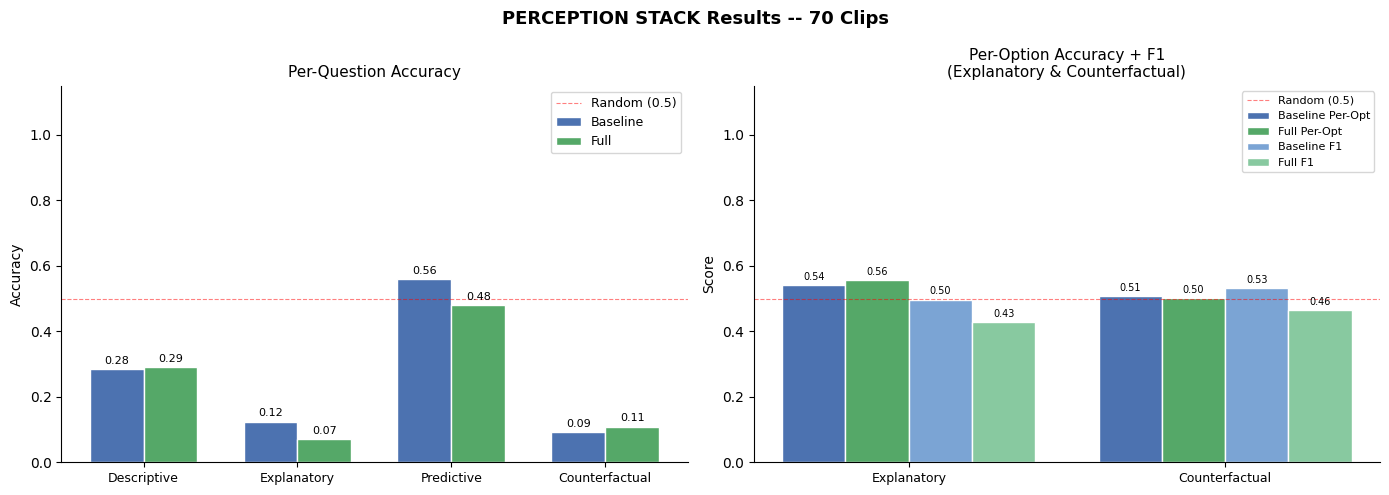

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot1_baseline_vs_full.jpg
Cell 4 complete.


In [7]:
# ── Cell 4 — Bar Charts: Baseline vs Enhanced (Full) ──────────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── Plot 1: Per-question accuracy -- baseline vs full ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PERCEPTION STACK Results -- {len(SELECTED_IDS)} Clips',
             fontsize=13, fontweight='bold')

x     = np.arange(len(Q_TYPES))
width = 0.35
colors = {'baseline': '#4C72B0', 'full': '#55A868'}

# ── Left: Per-question accuracy ────────────────────────────────────────────
ax = axes[0]
for i, cond in enumerate(['baseline', 'full']):
    vals = [all_metrics[cond][qt]['per_q_acc'] for qt in Q_TYPES]
    bars = ax.bar(x + i*width, vals, width, label=cond.capitalize(),
                  color=colors[cond], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Per-Question Accuracy', fontsize=11)
ax.set_xticks(x + width/2)
ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Right: Per-option accuracy + F1 for expl/cf only ──────────────────────
ax       = axes[1]
mc_types = ['explanatory', 'counterfactual']
x2       = np.arange(len(mc_types))
width2   = 0.2
colors2  = {
    'baseline_peropt': '#4C72B0',
    'full_peropt'    : '#55A868',
    'baseline_f1'    : '#7BA4D4',
    'full_f1'        : '#88C9A0'
}

for i, (cond, metric, label, color) in enumerate([
    ('baseline', 'per_opt_acc', 'Baseline Per-Opt', '#4C72B0'),
    ('full',     'per_opt_acc', 'Full Per-Opt',     '#55A868'),
    ('baseline', 'f1',         'Baseline F1',       '#7BA4D4'),
    ('full',     'f1',         'Full F1',           '#88C9A0'),
]):
    vals = [all_metrics[cond][qt][metric] or 0 for qt in mc_types]
    bars = ax.bar(x2 + i*width2, vals, width2, label=label,
                  color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_title('Per-Option Accuracy + F1\n(Explanatory & Counterfactual)', fontsize=11)
ax.set_xticks(x2 + width2*1.5)
ax.set_xticklabels([t.capitalize() for t in mc_types], fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot1_baseline_vs_full.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")
print("Cell 4 complete.")

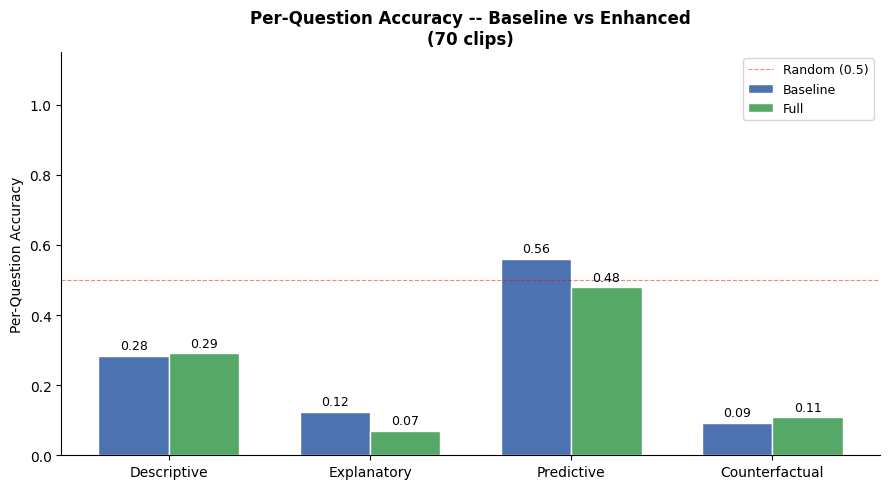

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot1_perq_accuracy.jpg


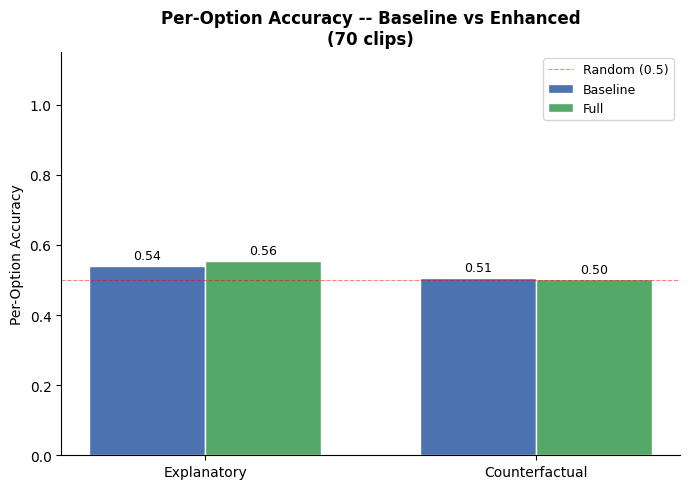

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot2_peropt_accuracy.jpg


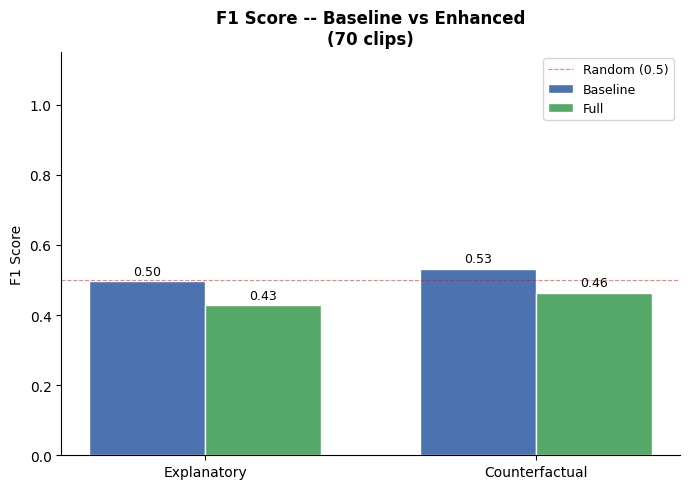

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot3_f1.jpg

Cell 4 complete.


In [8]:
# ── Cell 4 — Individual Bar Charts: Baseline vs Enhanced (Full) ────────────
import matplotlib.pyplot as plt
import numpy as np

colors = {'baseline': '#4C72B0', 'full': '#55A868'}
width  = 0.35
x      = np.arange(len(Q_TYPES))

# ── Plot 1: Per-question accuracy -- all 4 types ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for i, cond in enumerate(['baseline', 'full']):
    vals = [all_metrics[cond][qt]['per_q_acc'] for qt in Q_TYPES]
    bars = ax.bar(x + i*width, vals, width, label=cond.capitalize(),
                  color=colors[cond], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title(f'Per-Question Accuracy -- Baseline vs Enhanced\n({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=10)
ax.set_ylabel('Per-Question Accuracy', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot1_perq_accuracy.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 2: Per-option accuracy -- expl + cf only ─────────────────────────
mc_types = ['explanatory', 'counterfactual']
x2       = np.arange(len(mc_types))

fig, ax = plt.subplots(figsize=(7, 5))
for i, cond in enumerate(['baseline', 'full']):
    vals = [all_metrics[cond][qt]['per_opt_acc'] or 0 for qt in mc_types]
    bars = ax.bar(x2 + i*width, vals, width, label=cond.capitalize(),
                  color=colors[cond], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title(f'Per-Option Accuracy -- Baseline vs Enhanced\n({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x2 + width/2)
ax.set_xticklabels([t.capitalize() for t in mc_types], fontsize=10)
ax.set_ylabel('Per-Option Accuracy', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot2_peropt_accuracy.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 3: F1 -- expl + cf only ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for i, cond in enumerate(['baseline', 'full']):
    vals = [all_metrics[cond][qt]['f1'] or 0 for qt in mc_types]
    bars = ax.bar(x2 + i*width, vals, width, label=cond.capitalize(),
                  color=colors[cond], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title(f'F1 Score -- Baseline vs Enhanced\n({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x2 + width/2)
ax.set_xticklabels([t.capitalize() for t in mc_types], fontsize=10)
ax.set_ylabel('F1 Score', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot3_f1.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

print("\nCell 4 complete.")

---
# Cell 5 — Ablation Bar Chart: All 5 Conditions

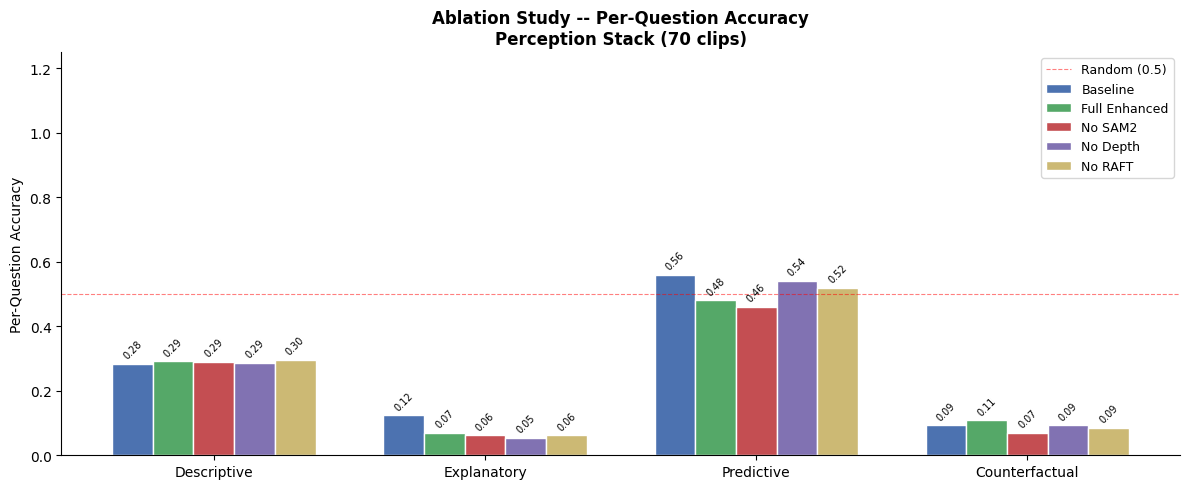

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot4_ablation_perq.jpg


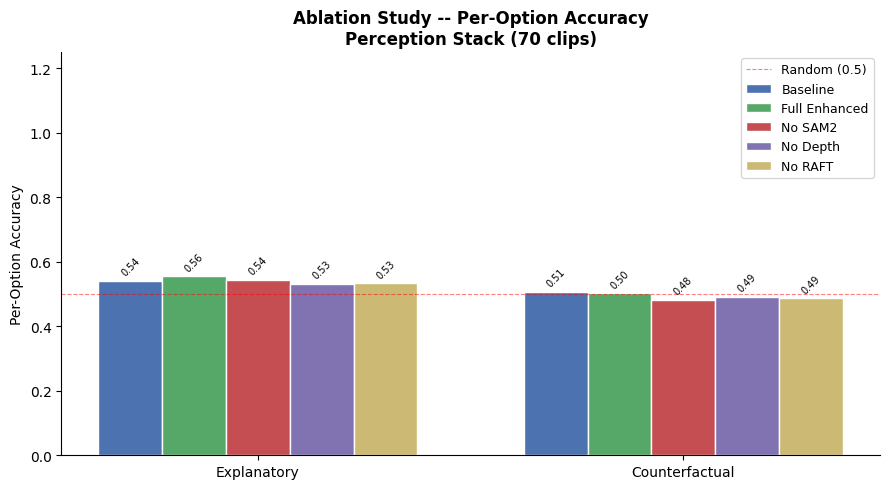

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot5_ablation_peropt.jpg


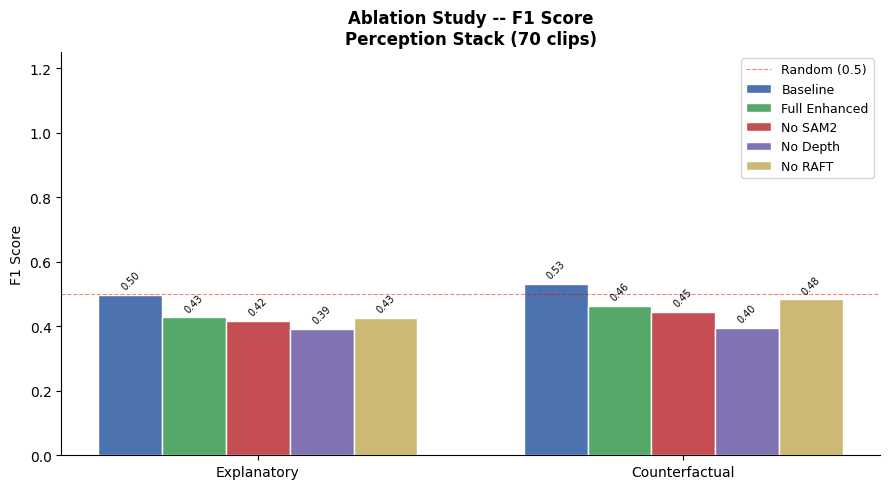

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot6_ablation_f1.jpg

Cell 5 complete.


In [9]:
# ── Cell 5 — Ablation Bar Chart: All 5 Conditions ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── Color palette for 5 conditions ────────────────────────────────────────
cond_colors = {
    'baseline': '#4C72B0',
    'full'    : '#55A868',
    'no_sam2' : '#C44E52',
    'no_depth': '#8172B2',
    'no_raft' : '#CCB974'
}
cond_labels = {
    'baseline': 'Baseline',
    'full'    : 'Full Enhanced',
    'no_sam2' : 'No SAM2',
    'no_depth': 'No Depth',
    'no_raft' : 'No RAFT'
}

x     = np.arange(len(Q_TYPES))
width = 0.15  # narrower bars to fit 5 conditions

# ── Plot 4: Ablation -- per-question accuracy ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for i, cond in enumerate(CONDITIONS):
    vals = [all_metrics[cond][qt]['per_q_acc'] for qt in Q_TYPES]
    bars = ax.bar(x + i*width, vals, width,
                  label=cond_labels[cond],
                  color=cond_colors[cond],
                  edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_title(f'Ablation Study -- Per-Question Accuracy\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=10)
ax.set_ylabel('Per-Question Accuracy', fontsize=10)
ax.set_ylim(0, 1.25)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot4_ablation_perq.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 5: Ablation -- per-option accuracy (expl + cf only) ──────────────
mc_types = ['explanatory', 'counterfactual']
x2       = np.arange(len(mc_types))

fig, ax = plt.subplots(figsize=(9, 5))
for i, cond in enumerate(CONDITIONS):
    vals = [all_metrics[cond][qt]['per_opt_acc'] or 0 for qt in mc_types]
    bars = ax.bar(x2 + i*width, vals, width,
                  label=cond_labels[cond],
                  color=cond_colors[cond],
                  edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_title(f'Ablation Study -- Per-Option Accuracy\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x2 + width*2)
ax.set_xticklabels([t.capitalize() for t in mc_types], fontsize=10)
ax.set_ylabel('Per-Option Accuracy', fontsize=10)
ax.set_ylim(0, 1.25)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot5_ablation_peropt.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 6: Ablation -- F1 (expl + cf only) ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for i, cond in enumerate(CONDITIONS):
    vals = [all_metrics[cond][qt]['f1'] or 0 for qt in mc_types]
    bars = ax.bar(x2 + i*width, vals, width,
                  label=cond_labels[cond],
                  color=cond_colors[cond],
                  edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_title(f'Ablation Study -- F1 Score\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x2 + width*2)
ax.set_xticklabels([t.capitalize() for t in mc_types], fontsize=10)
ax.set_ylabel('F1 Score', fontsize=10)
ax.set_ylim(0, 1.25)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot6_ablation_f1.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

print("\nCell 5 complete.")

---
# Cell 6 — Delta Accuracy Chart: Enhanced (Full) minus Baseline

/tmp/ipykernel_756/3921517922.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=10)


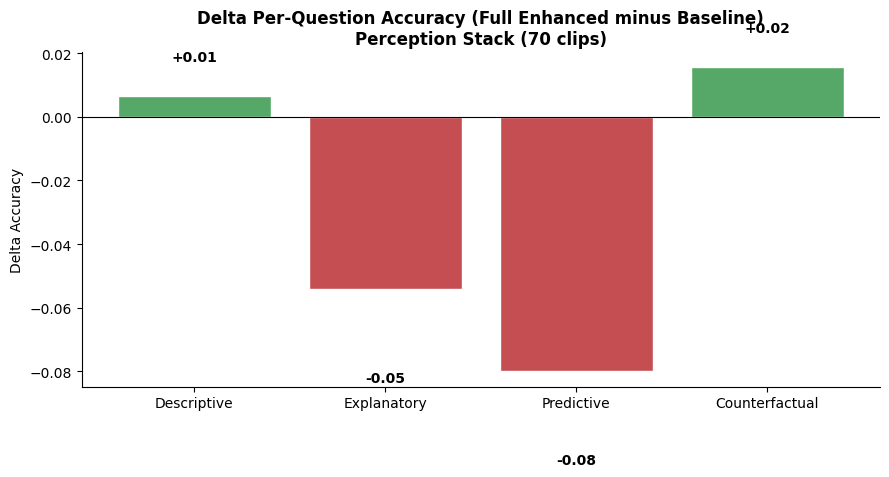

/tmp/ipykernel_756/3921517922.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([t.capitalize() for t in labels], fontsize=10)
/tmp/ipykernel_756/3921517922.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot7_delta_perq.jpg


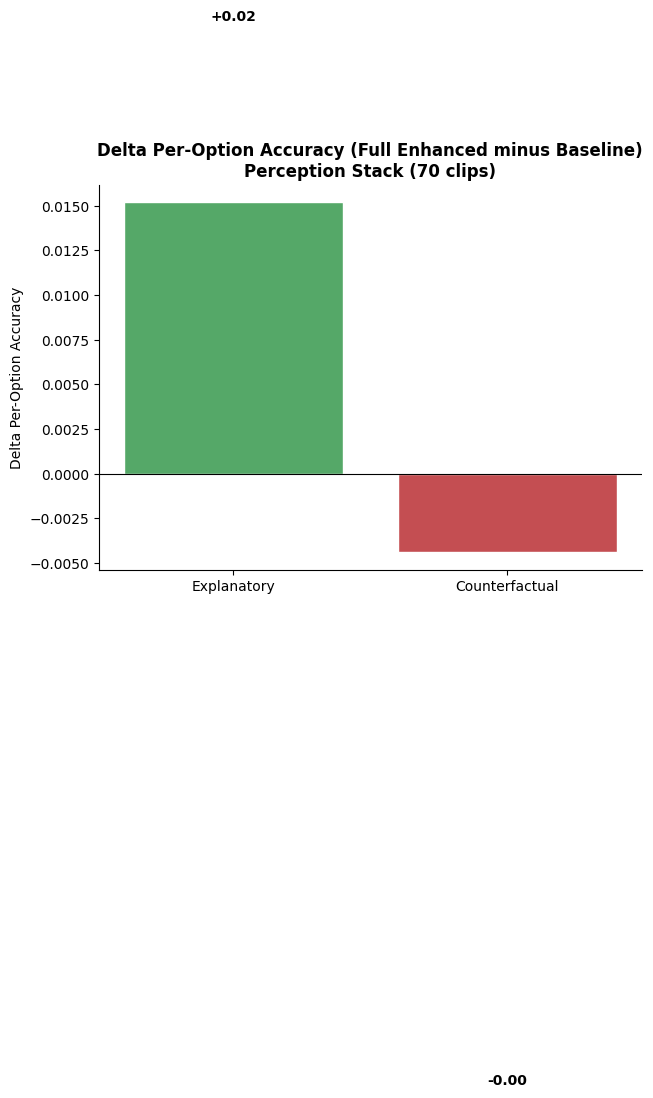

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot8_delta_peropt.jpg


/tmp/ipykernel_756/3921517922.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([t.capitalize() for t in labels], fontsize=10)


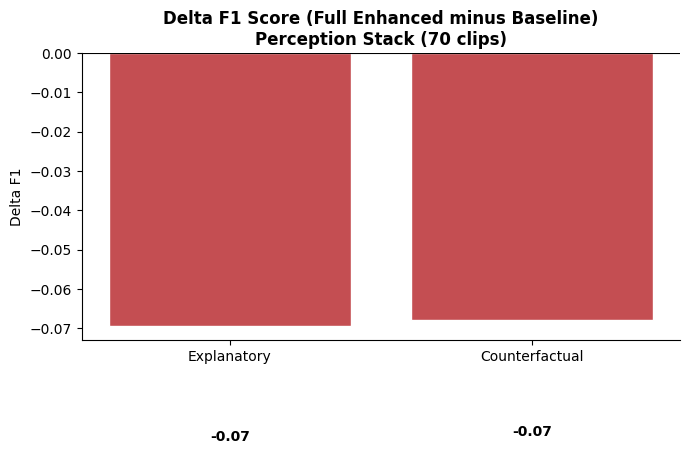

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot9_delta_f1.jpg

Cell 6 complete.


In [10]:
# ── Cell 6 — Delta Accuracy Chart: Enhanced (Full) minus Baseline ──────────
import matplotlib.pyplot as plt
import numpy as np

# ── Compute deltas ─────────────────────────────────────────────────────────
delta_perq    = []
delta_peropt  = []
delta_f1      = []

for qt in Q_TYPES:
    b = all_metrics['baseline'][qt]
    f = all_metrics['full'][qt]
    delta_perq.append(round(f['per_q_acc'] - b['per_q_acc'], 4))
    if b['per_opt_acc'] is not None and f['per_opt_acc'] is not None:
        delta_peropt.append((qt, round(f['per_opt_acc'] - b['per_opt_acc'], 4)))
    if b['f1'] is not None and f['f1'] is not None:
        delta_f1.append((qt, round(f['f1'] - b['f1'], 4)))

# ── Plot 7: Delta per-question accuracy -- all 4 types ────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#55A868' if d >= 0 else '#C44E52' for d in delta_perq]
bars = ax.bar(Q_TYPES, delta_perq, color=bar_colors, edgecolor='white')

for bar, val in zip(bars, delta_perq):
    ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Delta Per-Question Accuracy (Full Enhanced minus Baseline)\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=10)
ax.set_ylabel('Delta Accuracy', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot7_delta_perq.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 8: Delta per-option accuracy -- expl + cf only ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))
labels  = [t for t, _ in delta_peropt]
vals    = [v for _, v in delta_peropt]
colors  = ['#55A868' if v >= 0 else '#C44E52' for v in vals]
bars    = ax.bar(labels, vals, color=colors, edgecolor='white')

for bar, val in zip(bars, vals):
    ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Delta Per-Option Accuracy (Full Enhanced minus Baseline)\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels([t.capitalize() for t in labels], fontsize=10)
ax.set_ylabel('Delta Per-Option Accuracy', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot8_delta_peropt.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 9: Delta F1 -- expl + cf only ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
labels  = [t for t, _ in delta_f1]
vals    = [v for _, v in delta_f1]
colors  = ['#55A868' if v >= 0 else '#C44E52' for v in vals]
bars    = ax.bar(labels, vals, color=colors, edgecolor='white')

for bar, val in zip(bars, vals):
    ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Delta F1 Score (Full Enhanced minus Baseline)\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels([t.capitalize() for t in labels], fontsize=10)
ax.set_ylabel('Delta F1', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot9_delta_f1.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

print("\nCell 6 complete.")

---
# Cell 7 — Confusion Breakdown

  CONFUSION BREAKDOWN -- Baseline vs Full Enhanced
  Type                Fixed   Both Correct   Both Wrong   Broke It
  --------------------------------------------------------------------
  descriptive            89            135          462         84
  explanatory             5              4          108         12
  predictive             10             14           12         14
  counterfactual         10              4          107          8


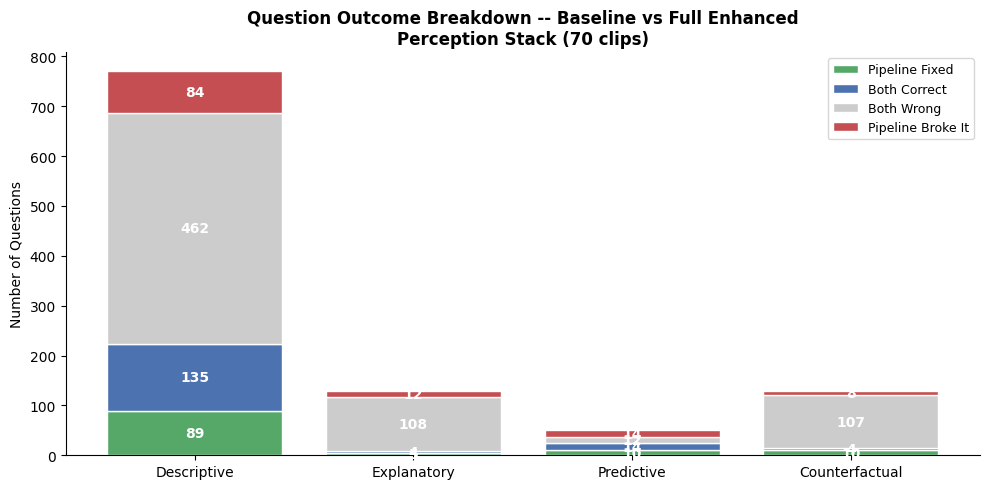


Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot10_confusion.jpg
Cell 7 complete.


In [11]:
# ── Cell 7 — Confusion Breakdown: pipeline_fixed / both_correct / both_wrong / pipeline_broke_it
import matplotlib.pyplot as plt
import numpy as np

def get_correct(qr):
    """Extract binary correct signal from a question result."""
    qt = qr.get('question_type')
    if qt in ('descriptive', 'predictive'):
        return qr.get('correct')
    else:
        return qr.get('per_question_correct')

def compute_confusion(baseline_results, enhanced_results):
    """
    Compare baseline vs enhanced (full) question by question.
    Returns counts per question type for each of 4 categories.
    """
    counts = {
        qt: {
            'pipeline_fixed'   : 0,
            'both_correct'     : 0,
            'both_wrong'       : 0,
            'pipeline_broke_it': 0
        }
        for qt in Q_TYPES
    }

    for vid_id in SELECTED_IDS:
        b_questions = {q['question_id']: q for q in baseline_results.get(vid_id, [])}
        e_questions = {q['question_id']: q for q in enhanced_results.get(vid_id, [])}

        for q_id, b_q in b_questions.items():
            qt  = b_q.get('question_type')
            e_q = e_questions.get(q_id)
            if e_q is None or qt not in counts:
                continue

            b_correct = get_correct(b_q)
            e_correct = get_correct(e_q)

            if b_correct is None or e_correct is None:
                continue

            if not b_correct and e_correct:
                counts[qt]['pipeline_fixed']    += 1
            elif b_correct and e_correct:
                counts[qt]['both_correct']       += 1
            elif not b_correct and not e_correct:
                counts[qt]['both_wrong']         += 1
            elif b_correct and not e_correct:
                counts[qt]['pipeline_broke_it']  += 1

    return counts


# ── Compute confusion ──────────────────────────────────────────────────────
confusion = compute_confusion(all_results['baseline'], all_results['full'])

# ── Print confusion table ──────────────────────────────────────────────────
print(f"{'='*70}")
print(f"  CONFUSION BREAKDOWN -- Baseline vs Full Enhanced")
print(f"{'='*70}")
print(f"  {'Type':<16} {'Fixed':>8} {'Both Correct':>14} {'Both Wrong':>12} {'Broke It':>10}")
print(f"  {'-'*68}")
for qt in Q_TYPES:
    c = confusion[qt]
    print(f"  {qt:<16} {c['pipeline_fixed']:>8} {c['both_correct']:>14} "
          f"{c['both_wrong']:>12} {c['pipeline_broke_it']:>10}")

# ── Plot 10: Stacked bar confusion breakdown ───────────────────────────────
categories = ['pipeline_fixed', 'both_correct', 'both_wrong', 'pipeline_broke_it']
cat_labels  = ['Pipeline Fixed', 'Both Correct', 'Both Wrong', 'Pipeline Broke It']
cat_colors  = ['#55A868', '#4C72B0', '#CCCCCC', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(Q_TYPES))
bottoms = np.zeros(len(Q_TYPES))

for cat, label, color in zip(categories, cat_labels, cat_colors):
    vals = [confusion[qt][cat] for qt in Q_TYPES]
    bars = ax.bar(x, vals, bottom=bottoms, label=label,
                  color=color, edgecolor='white')
    for bar, val, bot in zip(bars, vals, bottoms):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + val/2,
                    str(val), ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottoms += np.array(vals, dtype=float)

ax.set_title(f'Question Outcome Breakdown -- Baseline vs Full Enhanced\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=10)
ax.set_ylabel('Number of Questions', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot10_confusion.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"\nSaved -> {fig_path}")
print("Cell 7 complete.")

---
# Cell 8 — Qualitative Examples

In [12]:
# ── Cell 8 — Qualitative Examples ─────────────────────────────────────────

def get_correct(qr):
    qt = qr.get('question_type')
    if qt in ('descriptive', 'predictive'):
        return qr.get('correct')
    else:
        return qr.get('per_question_correct')

def find_interesting_examples(baseline_results, enhanced_results, n=5):
    """
    Find cases where:
    - pipeline_fixed: baseline wrong, enhanced correct
    - pipeline_broke_it: baseline correct, enhanced wrong
    Returns list of example dicts.
    """
    fixed    = []
    broke_it = []

    for vid_id in SELECTED_IDS:
        b_questions = {q['question_id']: q for q in baseline_results.get(vid_id, [])}
        e_questions = {q['question_id']: q for q in enhanced_results.get(vid_id, [])}

        for q_id, b_q in b_questions.items():
            qt  = b_q.get('question_type')
            e_q = e_questions.get(q_id)
            if e_q is None:
                continue

            b_correct = get_correct(b_q)
            e_correct = get_correct(e_q)
            if b_correct is None or e_correct is None:
                continue

            entry = {
                'vid_id'         : vid_id,
                'question_id'    : q_id,
                'question_type'  : qt,
                'question'       : b_q.get('question'),
                'ground_truth'   : b_q.get('ground_truth'),
                'b_predicted'    : b_q.get('predicted') or b_q.get('parsed_answer'),
                'e_predicted'    : e_q.get('predicted') or e_q.get('parsed_answer'),
                'b_reasoning'    : b_q.get('reasoning', ''),
                'e_reasoning'    : e_q.get('reasoning', ''),
                'b_correct'      : b_correct,
                'e_correct'      : e_correct,
                'context_string' : e_q.get('context_string', '')
            }

            if not b_correct and e_correct:
                fixed.append(entry)
            elif b_correct and not e_correct:
                broke_it.append(entry)

    return fixed[:n], broke_it[:n]


fixed_examples, broke_examples = find_interesting_examples(
    all_results['baseline'], all_results['full'], n=5
)

# ── Print pipeline_fixed examples ─────────────────────────────────────────
print(f"{'='*70}")
print(f"  PIPELINE FIXED -- Baseline Wrong, Enhanced Correct")
print(f"{'='*70}")
for i, ex in enumerate(fixed_examples):
    print(f"\n[{i+1}] Clip {ex['vid_id']} | {ex['question_type'].upper()} | Q{ex['question_id']}")
    print(f"  Question     : {ex['question']}")
    print(f"  Ground truth : {ex['ground_truth']}")
    print(f"  Baseline     : {ex['b_predicted']}  (WRONG)")
    print(f"  Enhanced     : {ex['e_predicted']}  (CORRECT)")
    print(f"  B Reasoning  : {ex['b_reasoning'][:200]}")
    print(f"  E Reasoning  : {ex['e_reasoning'][:200]}")
    print(f"  Context used :")
    for line in ex['context_string'].split('\n')[:10]:
        print(f"    {line}")
    if ex['context_string'].count('\n') > 10:
        print(f"    ...")

# ── Print pipeline_broke_it examples ──────────────────────────────────────
print(f"\n{'='*70}")
print(f"  PIPELINE BROKE IT -- Baseline Correct, Enhanced Wrong")
print(f"{'='*70}")
for i, ex in enumerate(broke_examples):
    print(f"\n[{i+1}] Clip {ex['vid_id']} | {ex['question_type'].upper()} | Q{ex['question_id']}")
    print(f"  Question     : {ex['question']}")
    print(f"  Ground truth : {ex['ground_truth']}")
    print(f"  Baseline     : {ex['b_predicted']}  (CORRECT)")
    print(f"  Enhanced     : {ex['e_predicted']}  (WRONG)")
    print(f"  B Reasoning  : {ex['b_reasoning'][:200]}")
    print(f"  E Reasoning  : {ex['e_reasoning'][:200]}")

print("\nCell 8 complete.")

  PIPELINE FIXED -- Baseline Wrong, Enhanced Correct

[1] Clip 10002 | DESCRIPTIVE | Q2
  Question     : How many spheres are moving when the video ends?
  Ground truth : 2
  Baseline     : 0  (WRONG)
  Enhanced     : 2  (CORRECT)
  B Reasoning  : The video ends with all the objects in their current positions.
  E Reasoning  : The blue metal cylinder and the gray metal sphere are moving when the video ends.
  Context used :
    Objects in this scene:
      - Blue metal cylinder
      - Brown metal cylinder
      - Cyan rubber cube
      - Gray metal sphere
      - Gray rubber sphere
      - Green metal cube
    
    Object overlaps detected: 5
      blue cylinder <-> green cube first overlap at frame 59 (1 pixels)
    ...

[2] Clip 10002 | DESCRIPTIVE | Q3
  Question     : What color is the object to collide with the blue object?
  Ground truth : green
  Baseline     : brown  (WRONG)
  Enhanced     : green  (CORRECT)
  B Reasoning  : The brown object is about to collide with the blue o

---
# Cell 9 — Parse Tier Distribution + Reasoning Coverage

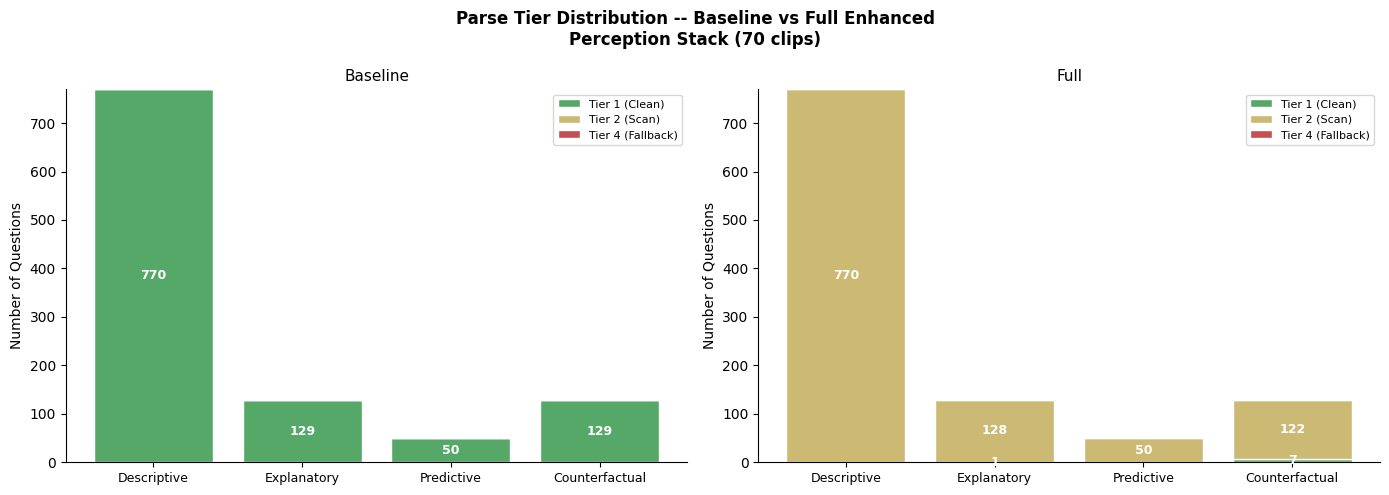

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot11_parse_tiers.jpg


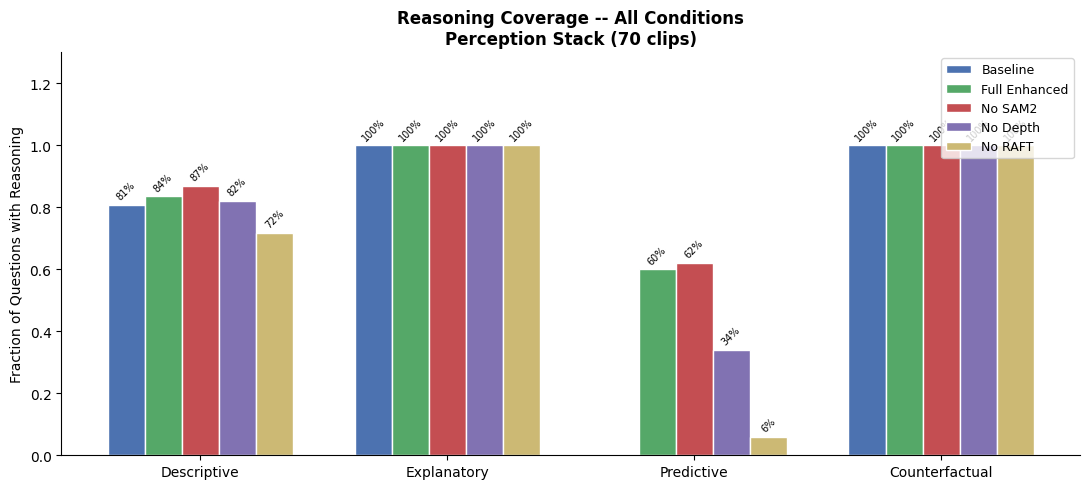

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot12_reasoning_coverage.jpg


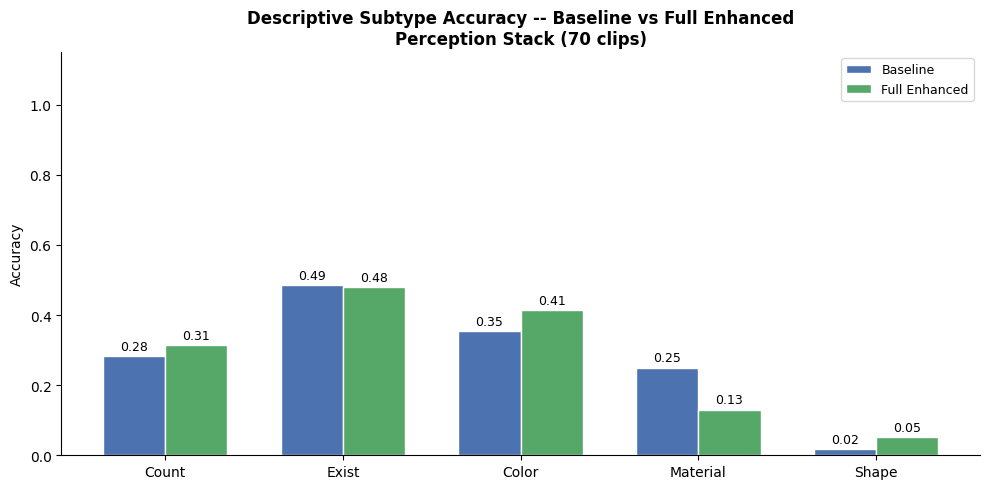

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/04_plot13_descriptive_subtypes.jpg

Cell 9 complete.


In [13]:
# ── Cell 9 — Parse Tier Distribution + Reasoning Coverage ─────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── Compute parse tier distribution per condition ──────────────────────────
def compute_parse_tiers(results):
    tiers = {qt: {1: 0, 2: 0, 4: 0} for qt in Q_TYPES}
    for vid_id, questions in results.items():
        for qr in questions:
            qt   = qr.get('question_type')
            tier = qr.get('parse_tier')
            if qt in tiers and tier in tiers[qt]:
                tiers[qt][tier] += 1
    return tiers

# ── Compute reasoning coverage per condition ───────────────────────────────
def compute_reasoning_coverage(results):
    coverage = {qt: {'with': 0, 'total': 0} for qt in Q_TYPES}
    for vid_id, questions in results.items():
        for qr in questions:
            qt = qr.get('question_type')
            if qt not in coverage:
                continue
            coverage[qt]['total'] += 1
            if qr.get('reasoning', '').strip():
                coverage[qt]['with'] += 1
    return {qt: round(v['with'] / v['total'], 4) if v['total'] > 0 else 0
            for qt, v in coverage.items()}


# ── Plot 11: Parse tier distribution -- baseline vs full ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Parse Tier Distribution -- Baseline vs Full Enhanced\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')

tier_colors = {1: '#55A868', 2: '#CCB974', 4: '#C44E52'}
tier_labels = {1: 'Tier 1 (Clean)', 2: 'Tier 2 (Scan)', 4: 'Tier 4 (Fallback)'}
x     = np.arange(len(Q_TYPES))
width = 0.25

for ax_idx, cond in enumerate(['baseline', 'full']):
    ax    = axes[ax_idx]
    tiers = compute_parse_tiers(all_results[cond])
    bottoms = np.zeros(len(Q_TYPES))

    for tier in [1, 2, 4]:
        vals = [tiers[qt][tier] for qt in Q_TYPES]
        bars = ax.bar(x, vals, bottom=bottoms,
                      label=tier_labels[tier],
                      color=tier_colors[tier],
                      edgecolor='white')
        for bar, val, bot in zip(bars, vals, bottoms):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bot + val/2, str(val),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        bottoms += np.array(vals, dtype=float)

    ax.set_title(cond.capitalize(), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=9)
    ax.set_ylabel('Number of Questions', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot11_parse_tiers.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 12: Reasoning coverage -- all 5 conditions ───────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x2      = np.arange(len(Q_TYPES))
width2  = 0.15

cond_colors = {
    'baseline': '#4C72B0',
    'full'    : '#55A868',
    'no_sam2' : '#C44E52',
    'no_depth': '#8172B2',
    'no_raft' : '#CCB974'
}
cond_labels = {
    'baseline': 'Baseline',
    'full'    : 'Full Enhanced',
    'no_sam2' : 'No SAM2',
    'no_depth': 'No Depth',
    'no_raft' : 'No RAFT'
}

for i, cond in enumerate(CONDITIONS):
    coverage = compute_reasoning_coverage(all_results[cond])
    vals     = [coverage[qt] for qt in Q_TYPES]
    bars     = ax.bar(x2 + i*width2, vals, width2,
                      label=cond_labels[cond],
                      color=cond_colors[cond],
                      edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.0%}', ha='center', va='bottom',
                    fontsize=7, rotation=45)

ax.set_title(f'Reasoning Coverage -- All Conditions\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x2 + width2*2)
ax.set_xticklabels([qt.capitalize() for qt in Q_TYPES], fontsize=10)
ax.set_ylabel('Fraction of Questions with Reasoning', fontsize=10)
ax.set_ylim(0, 1.3)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot12_reasoning_coverage.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ── Plot 13: Descriptive subtype accuracy -- baseline vs full ──────────────
def compute_descriptive_subtypes(results):
    subtypes = {}
    for vid_id, questions in results.items():
        for qr in questions:
            if qr.get('question_type') != 'descriptive':
                continue
            # infer subtype from ground truth
            gt = str(qr.get('ground_truth', ''))
            if gt.isdigit():
                st = 'count'
            elif gt in ('yes', 'no'):
                st = 'exist'
            elif gt in ('rubber', 'metal'):
                st = 'material'
            elif gt in ('sphere', 'cube', 'cylinder'):
                st = 'shape'
            else:
                st = 'color'
            if st not in subtypes:
                subtypes[st] = {'correct': 0, 'total': 0}
            subtypes[st]['total']   += 1
            subtypes[st]['correct'] += int(qr.get('correct', False))
    return {st: round(v['correct']/v['total'], 4) if v['total'] > 0 else 0
            for st, v in subtypes.items()}

subtypes_order = ['count', 'exist', 'color', 'material', 'shape']
fig, ax = plt.subplots(figsize=(10, 5))
x3      = np.arange(len(subtypes_order))
width3  = 0.35

for i, cond in enumerate(['baseline', 'full']):
    sub  = compute_descriptive_subtypes(all_results[cond])
    vals = [sub.get(st, 0) for st in subtypes_order]
    bars = ax.bar(x3 + i*width3, vals, width3,
                  label=cond_labels[cond],
                  color=cond_colors[cond],
                  edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title(f'Descriptive Subtype Accuracy -- Baseline vs Full Enhanced\nPerception Stack ({len(SELECTED_IDS)} clips)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x3 + width3/2)
ax.set_xticklabels([st.capitalize() for st in subtypes_order], fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '04_plot13_descriptive_subtypes.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

print("\nCell 9 complete.")

---
# Cell 10 — Runtime Table

In [14]:
# ── Cell 10 — Runtime Table ────────────────────────────────────────────────
import json, os
import numpy as np
import csv

# ── Collect runtimes from all JSON files ───────────────────────────────────
runtime_data = {cond: [] for cond in CONDITIONS}

for cond in CONDITIONS:
    folder = CONDITION_DIRS[cond]
    prefix = CONDITION_PREFIX[cond]
    for vid_id in SELECTED_IDS:
        fpath = os.path.join(folder, f"{prefix}_{vid_id:05d}.json")
        if not os.path.exists(fpath):
            continue
        with open(fpath, 'r') as f:
            data = json.load(f)
        runtime_data[cond].append(data.get('runtime_sec', 0))

# ── Print LLaVA runtime table ──────────────────────────────────────────────
print(f"{'='*60}")
print(f"  LLAVA RUNTIME -- Per Clip (seconds)")
print(f"{'='*60}")
print(f"  {'Condition':<16} {'N Clips':>8} {'Avg (s)':>10} {'Min (s)':>10} {'Max (s)':>10}")
print(f"  {'-'*58}")

for cond in CONDITIONS:
    times = runtime_data[cond]
    if not times:
        print(f"  {cond:<16} {'--':>8}")
        continue
    print(f"  {cond:<16} {len(times):>8} {np.mean(times):>10.1f} "
          f"{np.min(times):>10.1f} {np.max(times):>10.1f}")

# ── Save runtime CSV ───────────────────────────────────────────────────────
csv_path = os.path.join(ANALYSIS_DIR, "runtime_table.csv")
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'condition', 'n_clips', 'avg_sec', 'min_sec', 'max_sec'
    ])
    writer.writeheader()
    for cond in CONDITIONS:
        times = runtime_data[cond]
        if not times:
            continue
        writer.writerow({
            'condition': cond,
            'n_clips'  : len(times),
            'avg_sec'  : round(np.mean(times), 2),
            'min_sec'  : round(np.min(times), 2),
            'max_sec'  : round(np.max(times), 2)
        })

print(f"\nSaved -> {csv_path}")
print("Cell 10 complete.")

  LLAVA RUNTIME -- Per Clip (seconds)
  Condition         N Clips    Avg (s)    Min (s)    Max (s)
  ----------------------------------------------------------
  baseline               70       28.7       25.0       37.5
  full                   70       36.1       27.1       47.2
  no_sam2                70       36.8       27.0       48.6
  no_depth               70       32.6       23.2       47.9
  no_raft                70       29.9       21.9       42.1

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/analysis/runtime_table.csv
Cell 10 complete.


^ total wall-clock time to process all 10-15 questions for one clip under one condition.

---
# Cell 11 — Drive Space Check + Completion Summary

In [15]:
# ── Cell 11 — Drive Space Check + Completion Summary ──────────────────────
import os

print("── Output Files Summary ───────────────────────────────────────────────")

# ── Stage 4 LLaVA JSONs ───────────────────────────────────────────────────
total_bytes = 0
for cond in CONDITIONS:
    folder = CONDITION_DIRS[cond]
    prefix = CONDITION_PREFIX[cond]
    files  = [f for f in os.listdir(folder)
              if f.startswith(prefix) and f.endswith('.json') and 'error' not in f]
    size   = sum(os.path.getsize(os.path.join(folder, f)) for f in files)
    total_bytes += size
    print(f"  {cond:<12} : {len(files)} JSONs | {size/1e3:.1f} KB")

print(f"\n  Total LLaVA output : {total_bytes/1e6:.2f} MB")

# ── Figures ───────────────────────────────────────────────────────────────
print("\n── Figures saved (04_*) ───────────────────────────────────────────────")
fig_files = sorted([f for f in os.listdir(FIGURES_DIR) if f.startswith('04_')])
for f in fig_files:
    fpath = os.path.join(FIGURES_DIR, f)
    print(f"  {f}  ({os.path.getsize(fpath)/1e3:.1f} KB)")

# ── Analysis CSVs ─────────────────────────────────────────────────────────
print("\n── Analysis CSVs ──────────────────────────────────────────────────────")
csv_files = sorted([f for f in os.listdir(ANALYSIS_DIR) if f.endswith('.csv')])
for f in csv_files:
    fpath = os.path.join(ANALYSIS_DIR, f)
    print(f"  {f}  ({os.path.getsize(fpath)/1e3:.1f} KB)")

print("\nNotebook 04 complete.")
print("Next step: scale all notebooks to 50 clips.")

── Output Files Summary ───────────────────────────────────────────────
  baseline     : 70 JSONs | 689.1 KB
  full         : 70 JSONs | 3369.5 KB
  no_sam2      : 70 JSONs | 3122.9 KB
  no_depth     : 70 JSONs | 2461.8 KB
  no_raft      : 70 JSONs | 2124.5 KB

  Total LLaVA output : 11.77 MB

── Figures saved (04_*) ───────────────────────────────────────────────
  04_plot10_confusion.jpg  (46.4 KB)
  04_plot11_parse_tiers.jpg  (62.7 KB)
  04_plot12_reasoning_coverage.jpg  (59.9 KB)
  04_plot13_descriptive_subtypes.jpg  (40.5 KB)
  04_plot1_baseline_vs_full.jpg  (67.7 KB)
  04_plot1_perq_accuracy.jpg  (38.7 KB)
  04_plot2_peropt_accuracy.jpg  (31.0 KB)
  04_plot3_f1.jpg  (29.1 KB)
  04_plot4_ablation_perq.jpg  (53.7 KB)
  04_plot5_ablation_peropt.jpg  (43.2 KB)
  04_plot6_ablation_f1.jpg  (40.8 KB)
  04_plot7_delta_perq.jpg  (39.0 KB)
  04_plot8_delta_peropt.jpg  (44.1 KB)
  04_plot9_delta_f1.jpg  (31.1 KB)

── Analysis CSVs ──────────────────────────────────────────────────────
  bas

---